In [26]:
import sys
import gtsam
import gtsam.utils.plot as gtsam_plot
import matplotlib.pyplot as plt
import numpy as np

from typing import Optional
from functools import partial

In [27]:
p1 = gtsam.Pose2((1,1,np.pi/4))
p1.__getstate__()

('22 serialization::archive 20 1 0\n0 0 0 5.27393087579049347e-01 1.27323954473516254e+00 1 0\n1 7.07106781186547573e-01 7.07106781186547462e-01\n',)

In [28]:
# help(gtsam.Marginals)
gtsam.__dir__()

['__name__',
 '__doc__',
 '__package__',
 '__loader__',
 '__spec__',
 '__path__',
 '__file__',
 '__cached__',
 '__builtins__',
 'sys',
 'utils',
 'findExampleDataFile',
 'gtsam',
 'MT19937',
 'IndexPair',
 'DSFMapIndexPair',
 'Value',
 'GenericValueVector',
 'GenericValueMatrix',
 'GenericValuePoint2',
 'GenericValuePoint3',
 'GenericValueRot2',
 'GenericValueRot3',
 'GenericValuePose2',
 'GenericValuePose3',
 'GenericValueStereoPoint2',
 'GenericValueCal3_S2',
 'GenericValueCal3DS2',
 'GenericValueCal3Bundler',
 'GenericValueCal3Fisheye',
 'GenericValueCal3Unified',
 'GenericValueEssentialMatrix',
 'GenericValueCalibratedCamera',
 'GenericValueConstantBias',
 'isDebugVersion',
 'IndexPairSetAsArray',
 'linear_independent',
 'Symbol',
 'symbol_shorthand',
 'LabeledSymbol',
 'EdgeKey',
 'Ordering',
 'DotWriter',
 'VariableIndex',
 'Factor',
 'PrintKeyList',
 'PrintKeyVector',
 'PrintKeySet',
 'symbol',
 'symbolChr',
 'symbolIndex',
 'mrsymbol',
 'mrsymbolChr',
 'mrsymbolLabel',
 'mrsymb

In [29]:
print("Python executable:", sys.executable)
print("GTSAM module file:", gtsam.__file__)

Python executable: /Users/ovar/miniforge3/envs/gtsam_dbg/bin/python
GTSAM module file: /Users/ovar/miniforge3/envs/gtsam_dbg/lib/python3.10/site-packages/gtsam/__init__.py


## 2 Modeling Robot Motion
### 2.2 Creating a Factor Graph

In [30]:
# Create an empty nonlinear factor graph
graph = gtsam.NonlinearFactorGraph()

# Add a Gaussian prior on pose x_1
priorMean = gtsam.Pose2(0.0, 0.0, 0.0)
priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1])) 
graph.add(gtsam.PriorFactorPose2(1, priorMean, priorNoise))

# Add two odemetry factors
odometry = gtsam.Pose2(2.0, 0.0, 0.0)
odometryNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
graph.add(gtsam.BetweenFactorPose2(1, 2, odometry, odometryNoise))
graph.add(gtsam.BetweenFactorPose2(2, 3, odometry, odometryNoise))

graph.print("Factor Graph:\n")

Factor Graph:
size: 3

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];



### 2.4 Non-linear Optimization in GTSAM

In [31]:
1 # create (deliberatly inaccurate) initial estimate
initial = gtsam.Values()
initial.insert(1, gtsam.Pose2(0.5, 0.0, 0.2))
initial.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initial.insert(3, gtsam.Pose2(4.1, 0.1, 0.1))

result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
result.print("Result:\n")

Result:

Values with 3 values:
Value 1: (gtsam::Pose2)
(7.46978315e-16, -5.34409096e-16, -1.78381863e-16)

Value 2: (gtsam::Pose2)
(2, -1.09236636e-15, -2.48671179e-16)

Value 3: (gtsam::Pose2)
(4, -1.70076056e-15, -2.50943863e-16)



In [79]:
gaussian_fg = graph.linearize(result)
bayes_tree, factor_graph = gaussian_fg.eliminatePartialMultifrontal([1])

# bayes_tree.print("Bayes Tree:\n")
# factor_graph.print("Factor Graph:\n")
marg = factor_graph.eliminateMultifrontal()
fg = gtsam.GaussianFactorGraph(marg)
info = fg.augmentedHessian()[:-1,:-1]
cov = np.linalg.inv(info)
print(np.array2string(cov, formatter={"float_kind": lambda x: f"{x:.2f}"}))

[[0.13 0.00 0.00 0.13 0.00 0.00]
 [0.00 0.17 0.02 0.00 0.21 0.02]
 [0.00 0.02 0.02 0.00 0.06 0.02]
 [0.13 0.00 0.00 0.17 0.00 0.00]
 [0.00 0.21 0.06 0.00 0.37 0.06]
 [0.00 0.02 0.02 0.00 0.06 0.03]]


#### Full Posterio Inference

In [4]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=3, suppress=True)
# marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))

x1 covariance:
[[0.09 0.   0.  ]
 [0.   0.09 0.  ]
 [0.   0.   0.01]]
x2 covariance:
[[0.13 0.   0.  ]
 [0.   0.17 0.02]
 [0.   0.02 0.02]]
x3 covariance:
[[0.17 0.   0.  ]
 [0.   0.37 0.06]
 [0.   0.06 0.03]]


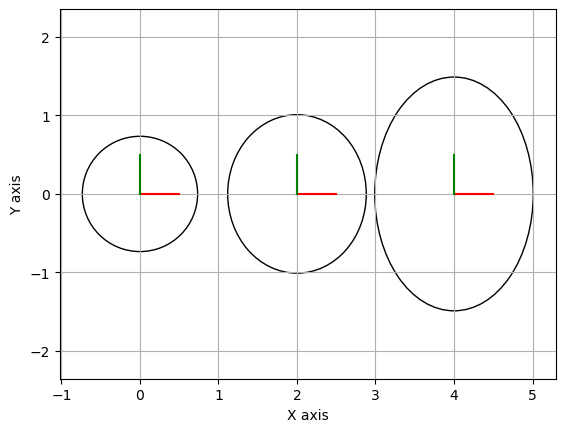

In [5]:
gtsam_plot.plot_pose2(0, result.atPose2(1), 0.5, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2(0, result.atPose2(2), 0.5, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2(0, result.atPose2(3), 0.5, marginals.marginalCovariance(3))
plt.axis('equal')
plt.grid('on')
plt.show()

## 3 Robot Localization
### 3.3 Using Custom Factors

https://gitlab.sintef.no/nix-flakes/gtsam/-/blob/master/python/CustomFactors.md 
https://github.com/borglab/gtsam/blob/develop/gtsam/nonlinear/doc/CustomFactor.ipynb 
https://github.com/borglab/gtsam/blob/develop/python/gtsam/examples/CustomFactorExample.py 

In [6]:
def error_gps(measurement: np.ndarray,
              this: gtsam.CustomFactor,
              values: gtsam.Values, 
              H: Optional[list[np.ndarray]]) -> np.ndarray:
    """GPS Factor error function
    :param measurement: GPS measurement, to be filled with `partial`
    :param this: gtsam.CustomFactor handle
    :param values: gtsam.Values
    :param H: Optional list of Jacobians
    :return: the unwhitened error
    """
    
    key = this.keys()[0]
    estimate_pose = values.atPose2(key)
    estimate_position = np.array([estimate_pose.x(), estimate_pose.y()])
    error = estimate_position - measurement

    if H is not None:
        H[0] = np.array([[1, 0, 0], [0, 1, 0]])

    return error

In [7]:
unaryNoise = gtsam.noiseModel.Diagonal.Sigmas([0.1, 0.1])
graph.add(gtsam.CustomFactor(unaryNoise, [1], partial(error_gps, np.array([0.0, 0.0]))))
graph.add(gtsam.CustomFactor(unaryNoise, [2], partial(error_gps, np.array([2.0, 0.0]))))
graph.add(gtsam.CustomFactor(unaryNoise, [3], partial(error_gps, np.array([4.0, 0.0]))))
graph.print()

NonlinearFactorGraph: size: 6

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 3: CustomFactor on 1
isotropic dim=2 sigma=0.1

Factor 4: CustomFactor on 2
isotropic dim=2 sigma=0.1

Factor 5: CustomFactor on 3
isotropic dim=2 sigma=0.1



In [8]:
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
result.print("Result:\n")

Result:

Values with 3 values:
Value 1: (gtsam::Pose2)
(-9.27935405e-17, 3.49728654e-18, 4.98922465e-19)

Value 2: (gtsam::Pose2)
(2, 3.67247512e-19, 5.49918357e-19)

Value 3: (gtsam::Pose2)
(4, -3.92959853e-19, 6.75866117e-19)



In [9]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=4, suppress=True)
# marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))

x1 covariance:
[[ 0.0076  0.     -0.    ]
 [ 0.      0.0081 -0.0015]
 [-0.     -0.0015  0.0045]]
x2 covariance:
[[ 0.0071  0.     -0.    ]
 [ 0.      0.0077 -0.0014]
 [-0.     -0.0014  0.0072]]
x3 covariance:
[[0.0083 0.     0.    ]
 [0.     0.0092 0.0026]
 [0.     0.0026 0.0172]]


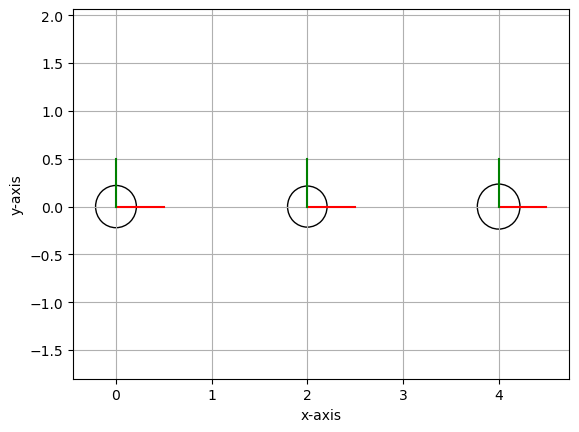

In [10]:
gtsam_plot.plot_pose2(0, result.atPose2(1), 0.5, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2(0, result.atPose2(2), 0.5, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2(0, result.atPose2(3), 0.5, marginals.marginalCovariance(3), ("x-axis", "y-axis", "theta-axis"))
plt.axis('equal')
plt.grid('on')
plt.show()


## 4 PoseSLAM

In [11]:
graph = gtsam.NonlinearFactorGraph()

priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1]))
graph.add(gtsam.PriorFactorPose2(1, gtsam.Pose2(0.0, 0.0, 0.0), priorNoise))

# Add odometry factors
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(2.0, 0.0, 0.0), model))
graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(2.0, 0.0, np.pi/2), model))
graph.add(gtsam.BetweenFactorPose2(3, 4, gtsam.Pose2(2.0, 0.0, np.pi/2), model))
graph.add(gtsam.BetweenFactorPose2(4, 5, gtsam.Pose2(2.0, 0.0, np.pi/2), model))

# Add pose constraint
graph.add(gtsam.BetweenFactorPose2(5, 2, gtsam.Pose2(2.0, 0.0, np.pi/2), model))


In [12]:
initialEstimate = gtsam.Values()
initialEstimate.insert(1, gtsam.Pose2(0.1, 0.2, 0.15))
initialEstimate.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initialEstimate.insert(3, gtsam.Pose2(4.1, -0.1, 0.1))
initialEstimate.insert(4, gtsam.Pose2(4.3, 1.6, 1.5))
initialEstimate.insert(5, gtsam.Pose2(2.5, 2.2, 2.9))

result = gtsam.LevenbergMarquardtOptimizer(graph, initialEstimate).optimize()
result.print()

Values with 5 values:
Value 1: (gtsam::Pose2)
(-4.04275228e-17, -5.2450694e-18, -6.74061164e-18)

Value 2: (gtsam::Pose2)
(2, -2.10573769e-17, -1.23156529e-17)

Value 3: (gtsam::Pose2)
(4, -9.65790365e-14, 1.57079633)

Value 4: (gtsam::Pose2)
(4, 2, -3.14159265)

Value 5: (gtsam::Pose2)
(2, 2, -1.57079633)



In [13]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=4, suppress=True)
#marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))
print("x4 covariance:\n" + str(marginals.marginalCovariance(4)))
print("x5 covariance:\n" + str(marginals.marginalCovariance(5)))


x1 covariance:
[[ 0.09 -0.    0.  ]
 [-0.    0.09 -0.  ]
 [ 0.   -0.    0.01]]
x2 covariance:
[[0.13 0.   0.  ]
 [0.   0.17 0.02]
 [0.   0.02 0.02]]
x3 covariance:
[[ 0.362  -0.      0.062 ]
 [-0.      0.162  -0.002 ]
 [ 0.062  -0.002   0.0265]]
x4 covariance:
[[ 0.268 -0.128  0.048]
 [-0.128  0.378 -0.068]
 [ 0.048 -0.068  0.028]]
x5 covariance:
[[ 0.202   0.036  -0.018 ]
 [ 0.036   0.26   -0.051 ]
 [-0.018  -0.051   0.0265]]


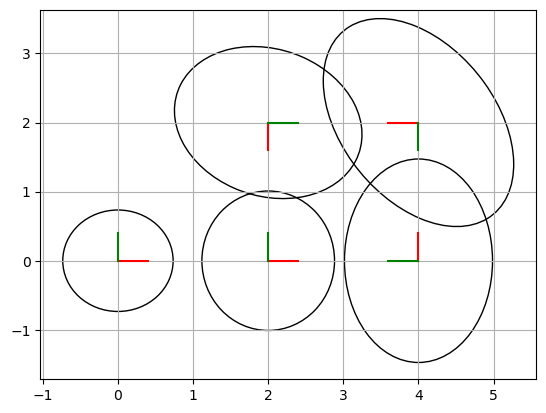

In [14]:
fig = plt.figure()
axes = fig.gca()

gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(1), 0.4, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(2), 0.4, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(3), 0.4, marginals.marginalCovariance(3))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(4), 0.4, marginals.marginalCovariance(4))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(5), 0.4, marginals.marginalCovariance(5))
plt.grid('on')

## 4.3 Reading and Optimizing Pose Graphs

In [38]:
datafile = gtsam.findExampleDataFile('w100.graph')
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 5*np.pi/180]))

[graph, initial] = gtsam.load2D(datafile, model)

In [40]:
initial

Values with 100 values:
Value 0: (gtsam::Pose2)
(0.000000000, 0.000000000, 0.000000000)

Value 1: (gtsam::Pose2)
(0.995595000, 0.083720400, 0.014672800)

Value 2: (gtsam::Pose2)
(2.046300000, 0.035256300, -0.033261500)

Value 3: (gtsam::Pose2)
(3.011730000, 0.001176940, -0.015390400)

Value 4: (gtsam::Pose2)
(4.009730000, -0.079019400, -0.028750000)

Value 5: (gtsam::Pose2)
(5.019600000, -0.066491200, -0.039715000)

Value 6: (gtsam::Pose2)
(5.027440000, 0.934341000, 1.517680000)

Value 7: (gtsam::Pose2)
(5.047750000, 1.893230000, 1.510330000)

Value 8: (gtsam::Pose2)
(5.153060000, 2.874180000, 1.498660000)

Value 9: (gtsam::Pose2)
(5.223040000, 3.874970000, 1.483640000)

Value 10: (gtsam::Pose2)
(5.235960000, 4.870410000, 1.479510000)

Value 11: (gtsam::Pose2)
(4.245810000, 4.947960000, 2.999440000)

Value 12: (gtsam::Pose2)
(3.227580000, 5.095510000, 2.994920000)

Value 13: (gtsam::Pose2)
(2.191420000, 5.168870000, 2.987070000)

Value 14: (gtsam::Pose2)
(1.131100000, 5.243290000, 2.97

In [16]:
# Add a Gaussian prior on pose x_0
priorMean = gtsam.Pose2(0, 0, 0)
priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.01]))
graph.add(gtsam.PriorFactorPose2(0, priorMean, priorNoise))

In [17]:
# Optimize using Levenberg-Marquardt optimization and get marginals
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()
marginals = gtsam.Marginals(graph, result)  

print("Graph error (initial):", graph.error(initial))
print("Graph error (result):", graph.error(result))

Graph error (initial): 15027.033279873533
Graph error (result): 213.3046076935409


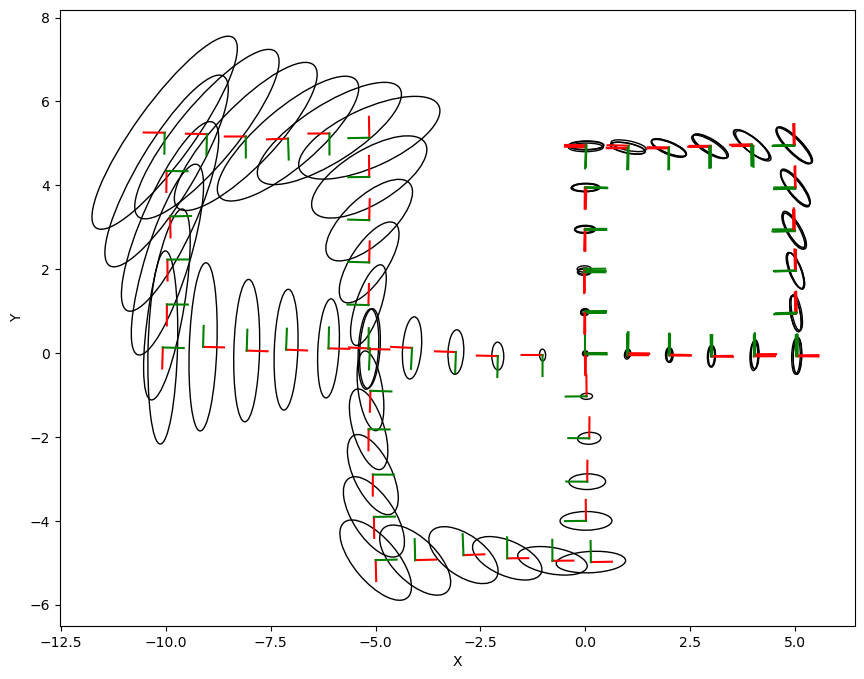

In [21]:
# Plot result
#gtsam_plot.plot_trajectory(fignum=1, values=initial, scale=0.5)

fig = plt.figure(1)
fig.set_size_inches(12, 8)
ax = fig.gca()  # 2D axes

poses2 = gtsam.utilities.allPose2s(result)
for k in poses2.keys():
    P = marginals.marginalCovariance(k)  # 3x3 Pose2 covariance
    gtsam_plot.plot_pose2_on_axes(ax, poses2.atPose2(k),
                                  axis_length=0.5, covariance=P)

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.show()

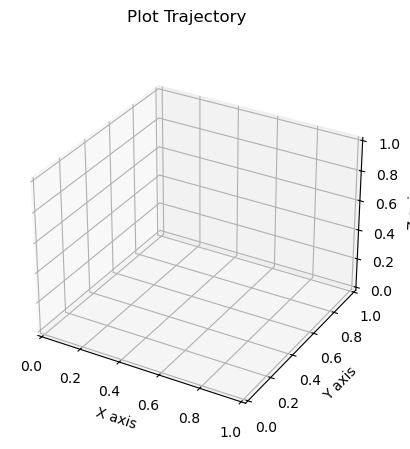

In [ ]:
datafile = gtsam.findExampleDataFile('sphere2500.txt')
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 0.1, 0.1, 0.1]))
[graph, initial] = gtsam.load3D(datafile) # initial is empty

# Plot initial estimate (requires a 3D plotting function, e.g., plot3DTrajectory)
gtsam_plot.plot_trajectory(fignum=1, values=initial, scale=0.5)

# Read again, now with all constraints, and optimize
# graph = gtsam.load3D(datafile, model)
# graph.add(gtsam.NonlinearEqualityPose3(0, initial.atPose3(0)))
# optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
# result = optimizer.optimizeSafely()

# Plot optimized result (requires a 3D plotting function)
# plot3DTrajectory(result, 'r-', False)
# plt.axis('equal')

## 5 Landmark-based SLAM

AttributeError: module 'gtsam' has no attribute 'visualSLAMGraph'